In [12]:
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dropout, Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam
import statistics

In [13]:
print('Inicio:',datetime.now())

Inicio: 2025-05-26 17:16:53.286980


In [14]:
# Lectura de datasets
malaria=pd.read_csv("malaria_esp_indexado.csv", sep=",",index_col=0)
humedad=pd.read_csv("humedad_mensual_esp.csv", sep=",",index_col=0)
temperatura=pd.read_csv("temperatura_mensual_esp.csv", sep=",",index_col=0)
viento=pd.read_csv("viento_mensual_esp.csv", sep=",",index_col=0)
precipitaciones=pd.read_csv("precipitaciones_mensuales_esp.csv", sep=",",index_col=0)
trends_malaria=pd.read_csv("malaria_trends.csv", sep=",",index_col=0)
trends_mosquito=pd.read_csv("mosquito_esp_trends.csv", sep=",",index_col=0)

In [15]:
# Unificación de datasets
malaria_tot=pd.concat([malaria,temperatura,humedad,viento,precipitaciones,trends_malaria,trends_mosquito],axis=1)
malaria_tot.index = pd.to_datetime(malaria_tot.index)
df=malaria_tot.dropna()

In [16]:
#Incluimos variables númericas para los meses y las semanas
df['mes']=df.index.month
df

,NumValue,TG,HU,FG,RR,malaria_trends,mosquito_esp_trends,mes
2008-01-01,17.0,99.334869,73.459677,29.963710,7.967742,92.0,101.0,1
2008-02-01,12.0,110.866995,73.563218,32.965517,13.936782,81.0,104.0,2
2008-03-01,13.0,116.403994,62.268817,45.931452,3.758065,102.0,165.0,3
2008-04-01,12.0,140.969841,62.141667,43.758333,13.594444,104.0,118.0,4
2008-05-01,16.0,162.611367,67.529570,39.828629,31.693548,105.0,142.0,5
...,...,...,...,...,...,...,...,...
2023-08-01,109.0,253.642089,51.881720,39.336694,5.758065,228.0,310.0,8
2023-09-01,123.0,217.963492,64.311111,31.881250,15.444444,238.0,256.0,9
2023-10-01,130.0,191.244240,64.061828,30.457661,15.044444,427.0,263.0,10
2023-11-01,73.0,138.869841,70.319444,35.458333,3.383333,327.0,102.0,11


In [17]:
df.corr(method='pearson')

,NumValue,TG,HU,FG,RR,malaria_trends,mosquito_esp_trends,mes
NumValue,1.000000,0.476037,-0.227200,-0.209661,-0.067466,0.108123,0.400531,0.406351
TG,0.476037,1.000000,-0.806971,0.278482,-0.370323,-0.058257,0.830216,0.289243
HU,-0.227200,-0.806971,1.000000,-0.551672,0.566537,-0.091603,-0.733481,0.076551
FG,-0.209661,0.278482,-0.551672,1.000000,-0.225093,-0.049140,0.340521,-0.391979
RR,-0.067466,-0.370323,0.566537,-0.225093,1.000000,-0.110418,-0.378323,0.074456
malaria_trends,0.108123,-0.058257,-0.091603,-0.049140,-0.110418,1.000000,0.053907,-0.074182
mosquito_esp_trends,0.400531,0.830216,-0.733481,0.340521,-0.378323,0.053907,1.000000,0.169688
mes,0.406351,0.289243,0.076551,-0.391979,0.074456,-0.074182,0.169688,1.000000


### Normalización y separación en test y train

In [18]:
def split_data(df,test_split=0.1):
    n=int(len(df)*test_split)
    train,test=df[:-n],df[-n:]
    return train, test

In [19]:
train,test=split_data(df)

In [20]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm=pd.DataFrame(norm.fit_transform(train),index=train.index,columns=train.columns)
test_norm=pd.DataFrame(norm.transform(test),index=test.index,columns=test.columns)

In [21]:
xtrainN=train_norm.iloc[:,1:]
xtestN=test_norm.iloc[:,1:]
ytrainN=train_norm.iloc[:,0]
ytestN=test_norm.iloc[:,0]
xtrainN.shape

(173, 7)

### Regresión lineal

In [22]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(xtrainN,ytrainN)
ypred=regr.predict(xtestN)
Y_rl=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
Y_rl['ypred']=pd.DataFrame(ypred,index=ytestN.index)
#Y_rl

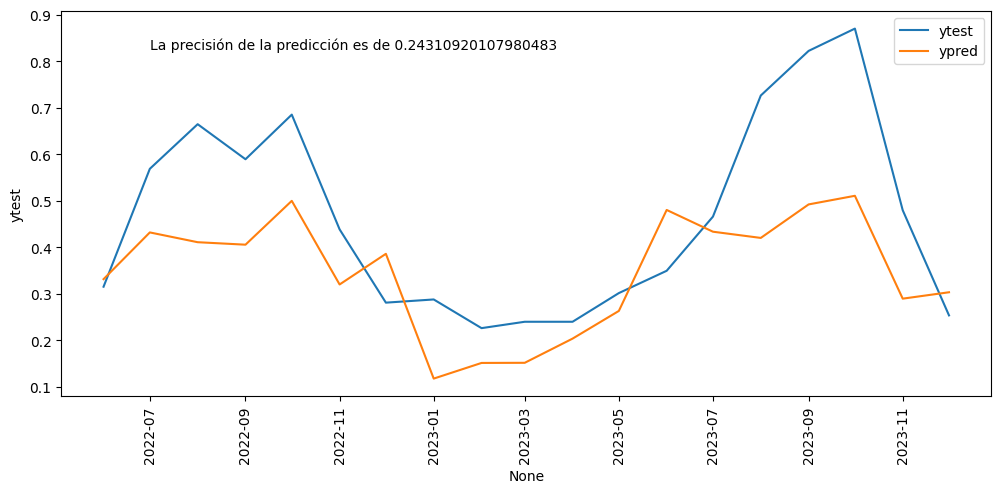

In [23]:
plt.figure(figsize=(12,5))
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ytest,label='ytest')
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 7, 1), 0.95*max(Y_rl.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rl.ytest, Y_rl.ypred)), fontsize=10)
plt.show()

### KNNeighbors

In [24]:
from sklearn.neighbors import KNeighborsRegressor
v=[]
for k in range(1,15):
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(xtrainN,ytrainN)
    ypred=knn.predict(xtestN.values.astype(np.float32))
    v.append(r2_score(ytestN, ypred))

print(v)

[-0.461484726860504, -0.3191986580471218, -0.2194109977497949, -0.11751394037807539, -0.010279113943442164, 0.08132806356403899, 0.15791719059019782, 0.1961635715708201, 0.3192464214779034, 0.37091773645025894, 0.37793039762045055, 0.42749556597254146, 0.48978888834300127, 0.46662912966896375]


In [25]:
knn=KNeighborsRegressor(n_neighbors=13)
knn.fit(xtrainN,ytrainN)
ypred_knn=knn.predict(xtestN.values.astype(np.float32))
Y_knn=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
Y_knn['ypred']=pd.DataFrame(ypred_knn,index=ytestN.index)
#Y_knn

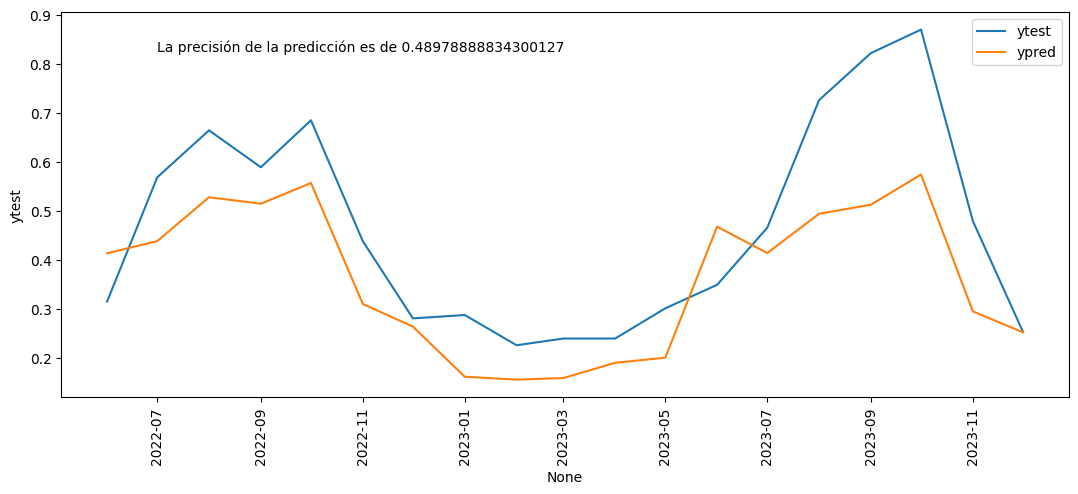

In [26]:
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ytest,label='ytest')
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 7, 1), 0.95*max(Y_knn.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_knn.ytest, Y_knn.ypred)), fontsize=10)
plt.show()

### Random Forest (Bootstrap=True)

In [27]:
rf=RandomForestRegressor(random_state=0) #Bootstrap=True
rf.fit(xtrainN,ytrainN)
ypred=rf.predict(xtestN.values.astype(np.float32))
Y_rf=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
Y_rf['ypred']=pd.DataFrame(ypred,index=ytestN.index)
#Y_rf

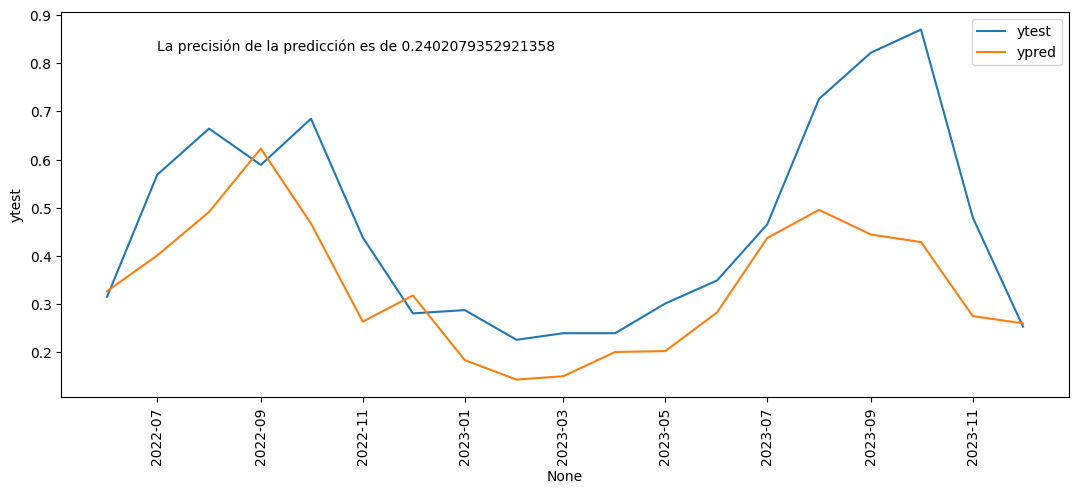

In [28]:
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ytest,label='ytest')
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 7, 1), 0.95*max(Y_rf.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rf.ytest, Y_rf.ypred)), fontsize=10)
plt.show()

### Random Forest (Bootstrap=False)

In [29]:
rf_b=RandomForestRegressor(random_state=0,bootstrap=False)
rf_b.fit(xtrainN,ytrainN)
ypred=rf_b.predict(xtestN.values.astype(np.float32))
Y_rf_b=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
Y_rf_b['ypred']=pd.DataFrame(ypred,index=ytestN.index)
#Y_rf_b

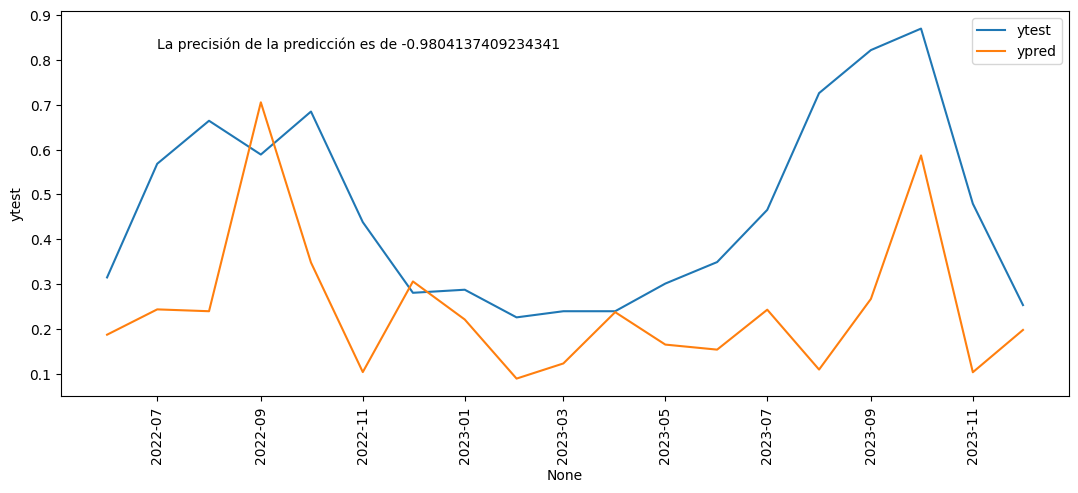

In [30]:
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_rf_b,x=Y_rf_b.index,y=Y_rf_b.ytest,label='ytest')
sns.lineplot(data=Y_rf_b,x=Y_rf_b.index,y=Y_rf_b.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 7, 1), 0.95*max(Y_rf_b.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rf_b.ytest, Y_rf_b.ypred)), fontsize=10)
plt.show()

### Gradient Boosting (learning rate=0.1)

In [31]:
gbr=GradientBoostingRegressor(random_state=0) #learning rate 0.1
gbr.fit(xtrainN,ytrainN)
ypred_gbr=gbr.predict(xtestN.values.astype(np.float32))
Y_gbr=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
Y_gbr['ypred']=pd.DataFrame(ypred_gbr,index=ytestN.index)
#Y_gbr

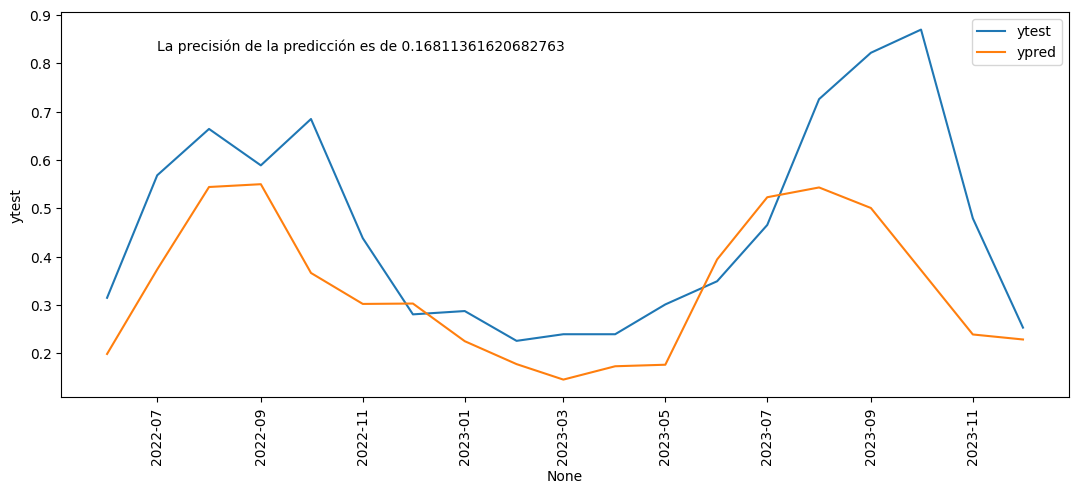

In [32]:
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ytest,label='ytest')
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 7, 1), 0.95*max(Y_gbr.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_gbr.ytest, Y_gbr.ypred)), fontsize=10)
plt.show()

### Gradient Boosting (learning rate=0.25)

In [33]:
gbr_lr=GradientBoostingRegressor(random_state=0,learning_rate=0.25) #learning rate 0.25
gbr_lr.fit(xtrainN,ytrainN)
ypred_gbr=gbr_lr.predict(xtestN.values.astype(np.float32))
Y_gbr_lr=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
Y_gbr_lr['ypred']=pd.DataFrame(ypred_gbr,index=ytestN.index)
#Y_gbr_lr

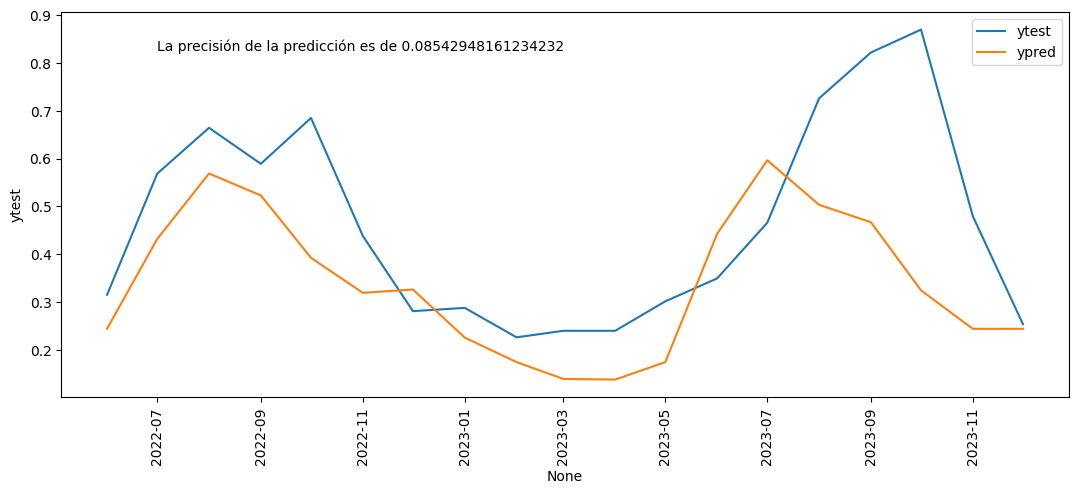

In [34]:
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ytest,label='ytest')
sns.lineplot(data=Y_gbr_lr,x=Y_gbr_lr.index,y=Y_gbr_lr.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 7, 1), 0.95*max(Y_gbr_lr.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_gbr_lr.ytest, Y_gbr_lr.ypred)), fontsize=10)
plt.show()

In [35]:
#Valores para modelos de aprendiazaje automático
ml1={'Regresion lineal': r2_score(Y_rl.ytest, Y_rl.ypred),
    'KNN (k=15)': r2_score(Y_knn.ytest, Y_knn.ypred),
    'Random Forest (bootstrap=True)': r2_score(Y_rf.ytest, Y_rf.ypred),
    'Random Forest (bootstrap=False)': r2_score(Y_rf_b.ytest, Y_rf_b.ypred),
    'Gradient Boosting (learning_rate=0.1)': r2_score(Y_gbr.ytest, Y_gbr.ypred),
    'Gradient Boosting (learning_rate=0.25)': r2_score(Y_gbr_lr.ytest, Y_gbr_lr.ypred)}

ml2={'Regresion lineal': mean_squared_error(Y_rl.ytest, Y_rl.ypred),
    'KNN (k=15)': mean_squared_error(Y_knn.ytest, Y_knn.ypred),
    'Random Forest (bootstrap=True)': mean_squared_error(Y_rf.ytest, Y_rf.ypred),
    'Random Forest (bootstrap=False)': mean_squared_error(Y_rf_b.ytest, Y_rf_b.ypred),
    'Gradient Boosting (learning_rate=0.1)': mean_squared_error(Y_gbr.ytest, Y_gbr.ypred),
    'Gradient Boosting (learning_rate=0.25)': mean_squared_error(Y_gbr_lr.ytest, Y_gbr_lr.ypred)}

ml3={'Regresion lineal': mean_absolute_error(Y_rl.ytest, Y_rl.ypred),
    'KNN (k=15)': mean_absolute_error(Y_knn.ytest, Y_knn.ypred),
    'Random Forest (bootstrap=True)': mean_absolute_error(Y_rf.ytest, Y_rf.ypred),
    'Random Forest (bootstrap=False)': mean_absolute_error(Y_rf_b.ytest, Y_rf_b.ypred),
    'Gradient Boosting (learning_rate=0.1)': mean_absolute_error(Y_gbr.ytest, Y_gbr.ypred),
    'Gradient Boosting (learning_rate=0.25)': mean_absolute_error(Y_gbr_lr.ytest, Y_gbr_lr.ypred)}

In [36]:
ML1=pd.DataFrame(ml1.values(),index=ml1.keys(),columns=['r2_score'])
ML2=pd.DataFrame(ml2.values(),index=ml2.keys(),columns=['mse'])
ML3=pd.DataFrame(ml3.values(),index=ml3.keys(),columns=['mae'])
ML=pd.concat([ML1,ML2,ML3],axis=1)
ml_max=ML[ML.r2_score==max(ML.r2_score)]

In [37]:
colores_r2=['#f1c40f' if i==max(ML.r2_score) else '#76d7c4' for i in ML.r2_score]
colores_mse=['#f1c40f' if i==min(ML.mse) else '#76d7c4' for i in ML.mse]
colores_mae=['#f1c40f' if i==min(ML.mae) else '#76d7c4' for i in ML.mae]

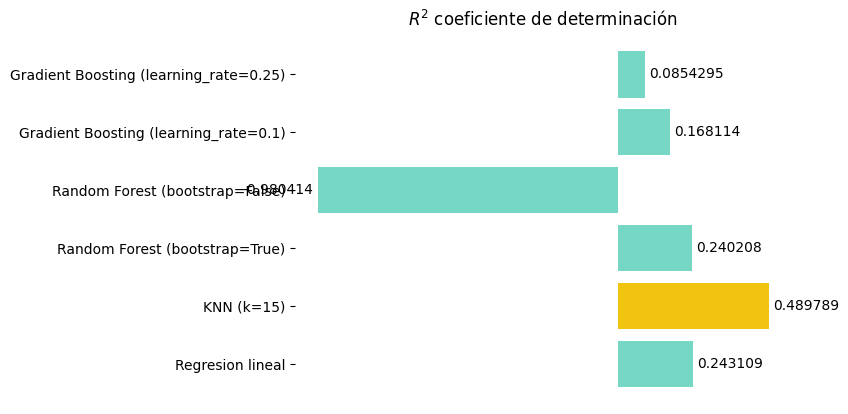

In [38]:
#Gráfica para los valores de r2
fig, ax = plt.subplots()
B=plt.barh(y=ML.index,width=ML.r2_score,color=colores_r2)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title(r'$R^2$ coeficiente de determinación')
ax.tick_params(bottom=False, labelbottom=False);

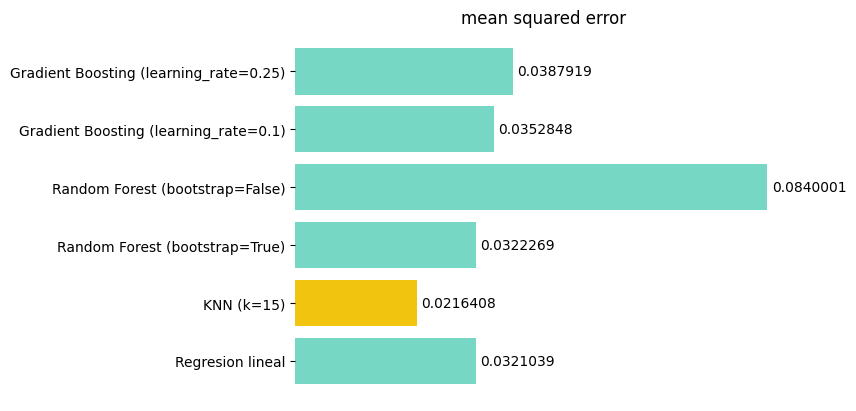

In [39]:
#Gráfica para los valores de mase
fig, ax = plt.subplots()
B=plt.barh(y=ML.index,width=ML.mse,color=colores_mse)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean squared error')
ax.tick_params(bottom=False, labelbottom=False);

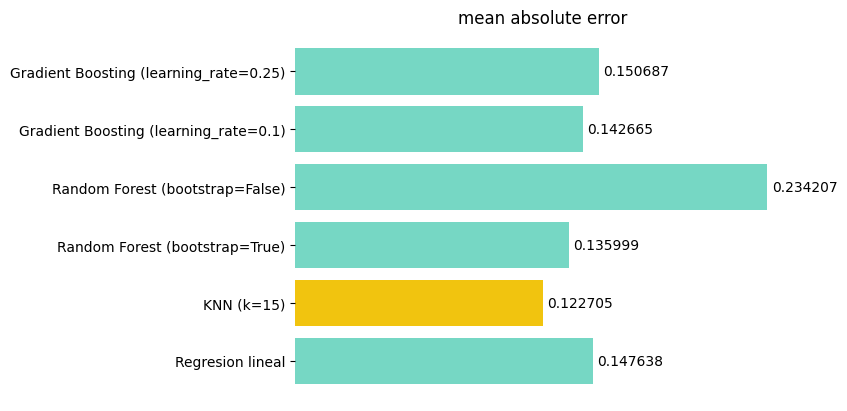

In [40]:
#Gráfica para los valores de mae
fig, ax = plt.subplots()
B=plt.barh(y=ML.index,width=ML.mae, color=colores_mae)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean absolute error')
ax.tick_params(bottom=False, labelbottom=False);

### Validación

In [41]:
xtrainN,xvalN=split_data(xtrainN)
ytrainN,yvalN=split_data(ytrainN)

### RNA (Adam learning_rate=0.005, 3 hidden layer (units=32), batch_size=32)

In [ ]:
Y_rna3=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna3=Sequential()
    rna3.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna3.add(Dropout(0.1))
    rna3.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna3.add(Dropout(0.1))
    rna3.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna3.add(Dropout(0.1))
    rna3.add(Dense(1))
    rna3.compile(optimizer=Adam(learning_rate=0.005),loss='mean_squared_error')
    rna3.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna3=rna3.predict(xtestN)
    Y_rna3['ypred_'+str(i)]=pd.DataFrame(ypred_rna3,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0672 - val_loss: 0.0174
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0220 - val_loss: 0.0727
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0773 - val_loss: 0.0208
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0367 - val_loss: 0.0165
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0311 - val_loss: 0.0169
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0289 - val_loss: 0.0210
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0328 - val_loss: 0.0273
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0380 - val_loss: 0.0258
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0358 - val_loss: 0.0211
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0335 - val_loss: 0.0178
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0304 - val_loss: 0.0176
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0315 - val_lo

In [ ]:
v3=[]
k3=[]
a3=[]
for i in range(4):
    v3.append(r2_score(Y_rna3.iloc[:,0], Y_rna3.iloc[:,i+1]))
    a3.append(mean_squared_error(Y_rna3.iloc[:,0], Y_rna3.iloc[:,i+1]))
    k3.append(mean_absolute_error(Y_rna3.iloc[:,0], Y_rna3.iloc[:,i+1]))

print(v3)
print(k3)
print(a3)

[0.1715363960368299, 0.38432049008632374, 0.3337154240770802, 0.38771855556786283]
[0.14572040132893535, 0.13303278550967607, 0.1291697139179612, 0.12513680755017725]
[0.035139644585386695, 0.026114314561769734, 0.02826075047673107, 0.025970184134400397]


### RNA (Adam learning_rate=0.003, 3 hidden layer (units=32), batch_size=32)

In [ ]:
Y_rna2=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna2=Sequential()
    rna2.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna2.add(Dropout(0.1))
    rna2.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna2.add(Dropout(0.1))
    rna2.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna2.add(Dropout(0.1))
    rna2.add(Dense(1))
    rna2.compile(optimizer=Adam(learning_rate=0.003),loss='mean_squared_error')
    rna2.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna2=rna2.predict(xtestN)
    Y_rna2['ypred_'+str(i)]=pd.DataFrame(ypred_rna2,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0787 - val_loss: 0.0408
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0526 - val_loss: 0.0214
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0311 - val_loss: 0.0223
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0371 - val_loss: 0.0355
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0486 - val_loss: 0.0276
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0397 - val_loss: 0.0211
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0336 - val_loss: 0.0190
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0312 - val_loss: 0.0189
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0309 - val_loss: 0.0198
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0315 - val_loss: 0.0207
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0335 - val_loss: 0.0208
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0342 - val_lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0723 - val_loss: 0.0276
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0336 - val_loss: 0.0227
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0332 - val_loss: 0.0434
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0538 - val_loss: 0.0297
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0406 - val_loss: 0.0209
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0341 - val_loss: 0.0188
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0311 - val_loss: 0.0191
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0301 - val_loss: 0.0214
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0322 - val_loss: 0.0236
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0341 - val_loss: 0.0227
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0348 - val_loss: 0.0191
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0761 - val_loss: 0.0354
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0450 - val_loss: 0.0176
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0260 - val_loss: 0.0348
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0475 - val_loss: 0.0356
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0475 - val_loss: 0.0242
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0380 - val_loss: 0.0195
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0320 - val_loss: 0.0187
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0315 - val_loss: 0.0196
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0328 - val_loss: 0.0214
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0324 - val_loss: 0.0225
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0358 - val_loss: 0.0213
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━

In [ ]:
a2=[]
k2=[]
v2=[]
for i in range(4):
    v2.append(r2_score(Y_rna2.iloc[:,0], Y_rna2.iloc[:,i+1]))
    a2.append(mean_squared_error(Y_rna2.iloc[:,0], Y_rna2.iloc[:,i+1]))
    k2.append(mean_absolute_error(Y_rna2.iloc[:,0], Y_rna2.iloc[:,i+1]))

print(v2)
print(k2)
print(a2)

[0.4387458892244134, 0.37835255574977944, 0.49676765383909094, 0.35966221877190185]
[0.11972932950489455, 0.12206350878235585, 0.11696174366919362, 0.1353954806891636]
[0.023805837553267012, 0.026367447095886967, 0.021344819136738757, 0.027160205879063308]


### RNA (Adam learning_rate=0.001, 3 hidden layer (units=32), batch_size=32)

In [ ]:
Y_rna1=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna1=Sequential()
    rna1.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna1.add(Dropout(0.1))
    rna1.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna1.add(Dropout(0.1))
    rna1.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna1.add(Dropout(0.1))
    rna1.add(Dense(1))
    rna1.compile(optimizer='adam',loss='mean_squared_error')
    rna1.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna1=rna1.predict(xtestN)
    Y_rna1['ypred_'+str(i)]=pd.DataFrame(ypred_rna1,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0832 - val_loss: 0.0535
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0747 - val_loss: 0.0456
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0650 - val_loss: 0.0368
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0540 - val_loss: 0.0275
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0420 - val_loss: 0.0195
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0323 - val_loss: 0.0166
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0286 - val_loss: 0.0216
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0347 - val_loss: 0.0280
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0422 - val_loss: 0.0277
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0428 - val_loss: 0.0238
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0386 - val_loss: 0.0204
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0375 - val_lo

In [ ]:
v1=[]
k1=[]
a1=[]
for i in range(4):
    v1.append(r2_score(Y_rna1.iloc[:,0], Y_rna1.iloc[:,i+1]))
    k1.append(mean_absolute_error(Y_rna1.iloc[:,0], Y_rna1.iloc[:,i+1]))
    a1.append(mean_squared_error(Y_rna1.iloc[:,0], Y_rna1.iloc[:,i+1]))

print(v1)
print(k1)
print(a1)

[0.49196799394513113, 0.5082014987005153, 0.5411461881293488, 0.517237848077366]
[0.11849892900070874, 0.1178504833555428, 0.11404703654182327, 0.11763516218866818]
[0.021548398801551624, 0.020859847627123996, 0.019462484276498614, 0.020476566932675976]


### RNA (Adam learning_rate=0.001, 2 hidden layer (units=32), batch_size=32)

In [ ]:
Y_rna4=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna4=Sequential()
    rna4.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna4.add(Dropout(0.1))
    rna4.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna4.add(Dropout(0.1))
    rna4.add(Dense(1))
    rna4.compile(optimizer='adam',loss='mean_squared_error')
    rna4.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna4=rna4.predict(xtestN)
    Y_rna4['ypred_'+str(i)]=pd.DataFrame(ypred_rna4,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0781 - val_loss: 0.0423
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0573 - val_loss: 0.0267
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0387 - val_loss: 0.0174
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0284 - val_loss: 0.0192
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0326 - val_loss: 0.0268
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0425 - val_loss: 0.0287
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0456 - val_loss: 0.0244
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0390 - val_loss: 0.0202
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0339 - val_loss: 0.0178
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0336 - val_loss: 0.0165
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0313 - val_loss: 0.0161
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0305 - val_lo

In [ ]:
v4=[]
k4=[]
a4=[]
for i in range(4):
    v4.append(r2_score(Y_rna4.iloc[:,0], Y_rna4.iloc[:,i+1]))
    k4.append(mean_absolute_error(Y_rna4.iloc[:,0], Y_rna4.iloc[:,i+1]))
    a4.append(mean_squared_error(Y_rna4.iloc[:,0], Y_rna4.iloc[:,i+1]))

print(v4)
print(k4)
print(a4)

[0.5209715505583764, 0.4816203906143085, 0.5064311701236963, 0.5363360377638865]
[0.11572290673347027, 0.11972479473882731, 0.11864570843588988, 0.11455791994188017]
[0.020318200315793053, 0.02198729690355181, 0.020934936884746392, 0.019666508899229208]


### RNA (Adam learning_rate=0.003, 2 hidden layer (units=32), batch_size=32)

In [ ]:
Y_rna5=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna5=Sequential()
    rna5.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna5.add(Dropout(0.1))
    rna5.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna5.add(Dropout(0.1))
    rna5.add(Dense(1))
    rna5.compile(optimizer=Adam(learning_rate=0.003),loss='mean_squared_error')
    rna5.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna5=rna5.predict(xtestN)
    Y_rna5['ypred_'+str(i)]=pd.DataFrame(ypred_rna5,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0666 - val_loss: 0.0212
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0254 - val_loss: 0.0312
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0508 - val_loss: 0.0332
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0506 - val_loss: 0.0180
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0326 - val_loss: 0.0139
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0288 - val_loss: 0.0137
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0271 - val_loss: 0.0163
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0325 - val_loss: 0.0176
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0318 - val_loss: 0.0157
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0313 - val_loss: 0.0133
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0297 - val_loss: 0.0122
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0278 - val_lo

In [ ]:
a5=[]
k5=[]
v5=[]
for i in range(4):
    v5.append(r2_score(Y_rna5.iloc[:,0], Y_rna5.iloc[:,i+1]))
    a5.append(mean_squared_error(Y_rna5.iloc[:,0], Y_rna5.iloc[:,i+1]))
    k5.append(mean_absolute_error(Y_rna5.iloc[:,0], Y_rna5.iloc[:,i+1]))

print(v5)
print(k5)
print(a5)

[0.5193487407402105, 0.47965432219008264, 0.5439952194260382, 0.5383252585494286]
[0.1143752346171178, 0.11450288266953412, 0.10824597605974795, 0.10917364592679388]
[0.020387032501017883, 0.022070688552053148, 0.019341641373202212, 0.019582135233239022]


### RNA (Adam learning_rate=0.005, 2 hidden layer (units=32), batch_size=32)

In [ ]:
Y_rna6=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna6=Sequential()
    rna6.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna6.add(Dropout(0.1))
    rna6.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna6.add(Dropout(0.1))
    rna6.add(Dense(1))
    rna6.compile(optimizer=Adam(learning_rate=0.005),loss='mean_squared_error')
    rna6.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna6=rna6.predict(xtestN)
    Y_rna6['ypred_'+str(i)]=pd.DataFrame(ypred_rna6,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0604 - val_loss: 0.0152
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0261 - val_loss: 0.0471
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0658 - val_loss: 0.0198
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0388 - val_loss: 0.0137
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0293 - val_loss: 0.0133
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0269 - val_loss: 0.0176
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0317 - val_loss: 0.0204
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0365 - val_loss: 0.0155
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0317 - val_loss: 0.0121
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0271 - val_loss: 0.0118
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0293 - val_loss: 0.0122
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0305 - val_lo

In [ ]:
v6=[]
k6=[]
a6=[]
for i in range(4):
    v6.append(r2_score(Y_rna6.iloc[:,0], Y_rna6.iloc[:,i+1]))
    a6.append(mean_squared_error(Y_rna6.iloc[:,0], Y_rna6.iloc[:,i+1]))
    k6.append(mean_absolute_error(Y_rna6.iloc[:,0], Y_rna6.iloc[:,i+1]))

print(v6)
print(a6)
print(k6)

[0.47792851304680717, 0.4977194663126183, 0.501696852325188, 0.5139203148426505]
[0.022143889498512117, 0.02130444759612829, 0.021135745036122044, 0.02061728154972184]
[0.11564264170927546, 0.11052460312069795, 0.10985137383630143, 0.11102571003756767]


### RNA (Adam learning_rate=0.001, 3 hidden layer (units=64), batch_size=64)

In [ ]:
Y_rna7=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna7=Sequential()
    rna7.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna7.add(Dropout(0.1))
    rna7.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna7.add(Dropout(0.1))
    rna7.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna7.add(Dropout(0.1))
    rna7.add(Dense(1))
    rna7.compile(optimizer='adam',loss='mean_squared_error')
    rna7.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna7=rna7.predict(xtestN)
    Y_rna7['ypred_'+str(i)]=pd.DataFrame(ypred_rna7,index=ytestN.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.1006 - val_loss: 0.0528
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0900 - val_loss: 0.0438
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0776 - val_loss: 0.0334
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0626 - val_loss: 0.0229
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0476 - val_loss: 0.0160
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0347 - val_loss: 0.0188
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0350 - val_loss: 0.0315
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0447 - val_loss: 0.0386
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0497 - val_loss: 0.0343
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0482 - val_loss: 0.0263
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0418 - val_loss: 0.0204
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0375 - val_l

In [ ]:
v7=[]
k7=[]
a7=[]
for i in range(4):
    v7.append(r2_score(Y_rna7.iloc[:,0], Y_rna7.iloc[:,i+1]))
    k7.append(mean_absolute_error(Y_rna7.iloc[:,0], Y_rna7.iloc[:,i+1]))
    a7.append(mean_squared_error(Y_rna7.iloc[:,0], Y_rna7.iloc[:,i+1]))

print(v7)
print(k7)
print(a7)

[0.5517565590540716, 0.5498283904962291, 0.5008040891254453, 0.5046188437034913]
[0.11771881343996948, 0.10848125761137134, 0.1082730327652957, 0.10892693089252767]
[0.019012440772559175, 0.01909422488172122, 0.02117361197606702, 0.021011807499187463]


### RNA (Adam learning_rate=0.003, 3 hidden layer (units=64), batch_size=64)

In [ ]:
Y_rna8=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna8=Sequential()
    rna8.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna8.add(Dropout(0.1))
    rna8.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna8.add(Dropout(0.1))
    rna8.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna8.add(Dropout(0.1))
    rna8.add(Dense(1))
    rna8.compile(optimizer=Adam(learning_rate=0.003),loss='mean_squared_error')
    rna8.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna8=rna8.predict(xtestN)
    Y_rna8['ypred_'+str(i)]=pd.DataFrame(ypred_rna8,index=ytestN.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0951 - val_loss: 0.0354
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0573 - val_loss: 0.0166
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0308 - val_loss: 0.0581
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0737 - val_loss: 0.0326
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0499 - val_loss: 0.0174
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0375 - val_loss: 0.0151
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0369 - val_loss: 0.0148
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0332 - val_loss: 0.0157
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0342 - val_loss: 0.0193
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0352 - val_loss: 0.0238
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0393 - val_loss: 0.0239
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0403 - val_l

In [ ]:
v8=[]
k8=[]
a8=[]
for i in range(4):
    v8.append(r2_score(Y_rna8.iloc[:,0], Y_rna8.iloc[:,i+1]))
    k8.append(mean_absolute_error(Y_rna8.iloc[:,0], Y_rna8.iloc[:,i+1]))
    a8.append(mean_squared_error(Y_rna8.iloc[:,0], Y_rna8.iloc[:,i+1]))

print(v8)
print(k8)
print(a8)

[0.48513118086183205, 0.19117442904957394, 0.23086959181901157, 0.48773298118054]
[0.11619926297200527, 0.13070417804174828, 0.14062047605258401, 0.11991343355557002]
[0.021838385206137876, 0.034306688862138536, 0.03262300124471712, 0.021728028712449825]


### RNA (Adam learning_rate=0.005, 3 hidden layer (units=64), batch_size=64)

In [ ]:
Y_rna9=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna9=Sequential()
    rna9.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna9.add(Dropout(0.1))
    rna9.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna9.add(Dropout(0.1))
    rna9.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna9.add(Dropout(0.1))
    rna9.add(Dense(1))
    rna9.compile(optimizer=Adam(learning_rate=0.005),loss='mean_squared_error')
    rna9.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna9=rna9.predict(xtestN)
    Y_rna9['ypred_'+str(i)]=pd.DataFrame(ypred_rna9,index=ytestN.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0926 - val_loss: 0.0260
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0416 - val_loss: 0.0475
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0597 - val_loss: 0.0384
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0477 - val_loss: 0.0218
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0389 - val_loss: 0.0180
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0369 - val_loss: 0.0179
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0355 - val_loss: 0.0200
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0344 - val_loss: 0.0242
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0360 - val_loss: 0.0267
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0396 - val_loss: 0.0237
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0406 - val_loss: 0.0179
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0334 - val_l

In [ ]:
v9=[]
k9=[]
a9=[]
for i in range(4):
    v9.append(r2_score(Y_rna9.iloc[:,0], Y_rna9.iloc[:,i+1]))
    k9.append(mean_absolute_error(Y_rna9.iloc[:,0], Y_rna9.iloc[:,i+1]))
    a9.append(mean_squared_error(Y_rna9.iloc[:,0], Y_rna9.iloc[:,i+1]))

print(v9)
print(k9)
print(a9)

[0.11107858846849161, 0.1931148790802122, 0.3149169780234231, 0.1508504136192771]
[0.15240504733933422, 0.14364524085743444, 0.13672328974028328, 0.15201332673118884]
[0.03770398882477172, 0.03422438382895888, 0.02905809475344167, 0.03601704953905643]


### RNA (Adam learning_rate=0.001, 2 hidden layer (units=64), batch_size=64)

In [ ]:
Y_rna10=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna10=Sequential()
    rna10.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna10.add(Dropout(0.1))
    rna10.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna10.add(Dropout(0.1))
    rna10.add(Dense(1))
    rna10.compile(optimizer='Adam',loss='mean_squared_error')
    rna10.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna10=rna10.predict(xtestN)
    Y_rna10['ypred_'+str(i)]=pd.DataFrame(ypred_rna10,index=ytestN.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 0.0976 - val_loss: 0.0454
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0783 - val_loss: 0.0323
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0607 - val_loss: 0.0213
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0461 - val_loss: 0.0152
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0346 - val_loss: 0.0170
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0346 - val_loss: 0.0253
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0406 - val_loss: 0.0323
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0485 - val_loss: 0.0324
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0470 - val_loss: 0.0274
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0425 - val_loss: 0.0220
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0393 - val_loss: 0.0179
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0360 - val_l

In [ ]:
v10=[]
k10=[]
a10=[]
for i in range(4):
    v10.append(r2_score(Y_rna10.iloc[:,0], Y_rna10.iloc[:,i+1]))
    a10.append(mean_squared_error(Y_rna10.iloc[:,0], Y_rna10.iloc[:,i+1]))
    k10.append(mean_absolute_error(Y_rna10.iloc[:,0], Y_rna10.iloc[:,i+1]))

print(a10)
print(v10)
print(k10)

[0.01837637479059906, 0.018849329073323137, 0.015508724443313386, 0.018893278988014964]
[0.5667526559694114, 0.5556021331283707, 0.6343613062460425, 0.5545659557523875]
[0.11349972056543219, 0.11474108871102076, 0.10394475599932174, 0.11725963121407655]


### RNA (Adam learning_rate=0.003, 2 hidden layer (units=64), batch_size=64)

In [ ]:
Y_rna11=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna11=Sequential()
    rna11.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna11.add(Dropout(0.1))
    rna11.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna11.add(Dropout(0.1))
    rna11.add(Dense(1))
    rna11.compile(optimizer=Adam(learning_rate=0.003),loss='mean_squared_error')
    rna11.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna11=rna11.predict(xtestN)
    Y_rna11['ypred_'+str(i)]=pd.DataFrame(ypred_rna11,index=ytestN.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - loss: 0.0886 - val_loss: 0.0249
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0442 - val_loss: 0.0260
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0417 - val_loss: 0.0479
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0611 - val_loss: 0.0327
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0472 - val_loss: 0.0193
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0381 - val_loss: 0.0149
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0340 - val_loss: 0.0140
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0331 - val_loss: 0.0147
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0325 - val_loss: 0.0172
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0322 - val_loss: 0.0197
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0354 - val_loss: 0.0197
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0368 - val_l

In [ ]:
v11=[]
k11=[]
a11=[]
for i in range(4):
    v11.append(r2_score(Y_rna11.iloc[:,0], Y_rna11.iloc[:,i+1]))
    a11.append(mean_squared_error(Y_rna11.iloc[:,0], Y_rna11.iloc[:,i+1]))
    k11.append(mean_absolute_error(Y_rna11.iloc[:,0], Y_rna11.iloc[:,i+1]))

print(a11)
print(v11)
print(k11)

[0.01633676115739938, 0.022008356410212943, 0.017418772583966433, 0.018938354799306206]
[0.6148392453811814, 0.4811238848871725, 0.589329394710812, 0.5535032338747328]
[0.10266877423969208, 0.11842339756081409, 0.10961412906474835, 0.11304288163577042]


### RNA (Adam learning_rate=0.005, 2 hidden layer (units=64), batch_size=64)

In [ ]:
Y_rna12=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rna12=Sequential()
    rna12.add(Dense(units=64,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna12.add(Dropout(0.1))
    rna12.add(Dense(units=64,kernel_initializer='uniform',activation='relu'))
    rna12.add(Dropout(0.1))
    rna12.add(Dense(1))
    rna12.compile(optimizer=Adam(learning_rate=0.005),loss='mean_squared_error')
    rna12.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna12=rna12.predict(xtestN)
    Y_rna12['ypred_'+str(i)]=pd.DataFrame(ypred_rna12,index=ytestN.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0794 - val_loss: 0.0171
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0318 - val_loss: 0.0567
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0667 - val_loss: 0.0242
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0448 - val_loss: 0.0137
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0341 - val_loss: 0.0126
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0319 - val_loss: 0.0144
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0317 - val_loss: 0.0204
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0361 - val_loss: 0.0206
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0372 - val_loss: 0.0146
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0334 - val_loss: 0.0106
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0293 - val_loss: 0.0096
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0290 - val_l

In [ ]:
v12=[]
k12=[]
a12=[]
for i in range(4):
    v12.append(r2_score(Y_rna12.iloc[:,0], Y_rna12.iloc[:,i+1]))
    a12.append(mean_squared_error(Y_rna12.iloc[:,0], Y_rna12.iloc[:,i+1]))
    k12.append(mean_absolute_error(Y_rna12.iloc[:,0], Y_rna12.iloc[:,i+1]))

print(a12)
print(v12)
print(k12)

[0.024163022457641865, 0.020704680908776633, 0.027960217118754634, 0.01922146739014567]
[0.4303247826181533, 0.5118597593407113, 0.340800895538105, 0.5468284800432226]
[0.11656514060480096, 0.11205501941978803, 0.12413082730022368, 0.11046192581780798]


In [ ]:
rna1={'RNA (Adam lr=0.001, 3 hidden layers (32 units), batch_size=32)': statistics.mean(v1),
    'RNA (Adam lr=0.003, 3 hidden layers (32 units), batch_size=32)': statistics.mean(v2),
    'RNA (Adam lr=0.005, 3 hidden layers (32 units), batch_size=32)': statistics.mean(v3),
    'RNA (Adam lr=0.001, 2 hidden layers (32 units), batch_size=32)': statistics.mean(v4),
    'RNA (Adam lr=0.003, 2 hidden layers (32 units), batch_size=32)': statistics.mean(v5),
    'RNA (Adam lr=0.005, 2 hidden layers (32 units), batch_size=32)': statistics.mean(v6),
    'RNA (Adam lr=0.001, 3 hidden layers (64 units), batch_size=64)': statistics.mean(v7),
    'RNA (Adam lr=0.003, 3 hidden layers (64 units), batch_size=64)': statistics.mean(v8),
    'RNA (Adam lr=0.005, 3 hidden layers (64 units), batch_size=64)': statistics.mean(v9),
    'RNA (Adam lr=0.001, 2 hidden layers (64 units), batch_size=64)': statistics.mean(v10),
    'RNA (Adam lr=0.003, 2 hidden layers (64 units), batch_size=64)': statistics.mean(v11),
    'RNA (Adam lr=0.005, 2 hidden layers (64 units), batch_size=64)': statistics.mean(v12)}

rna2={'RNA (Adam lr=0.001, 3 hidden layers (32 units), batch_size=32)': statistics.mean(a1),
    'RNA (Adam lr=0.003, 3 hidden layers (32 units), batch_size=32)': statistics.mean(a2),
    'RNA (Adam lr=0.005, 3 hidden layers (32 units), batch_size=32)': statistics.mean(a3),
    'RNA (Adam lr=0.001, 2 hidden layers (32 units), batch_size=32)': statistics.mean(a4),
    'RNA (Adam lr=0.003, 2 hidden layers (32 units), batch_size=32)': statistics.mean(a5),
    'RNA (Adam lr=0.005, 2 hidden layers (32 units), batch_size=32)': statistics.mean(a6),
    'RNA (Adam lr=0.001, 3 hidden layers (64 units), batch_size=64)': statistics.mean(a7),
    'RNA (Adam lr=0.003, 3 hidden layers (64 units), batch_size=64)': statistics.mean(a8),
    'RNA (Adam lr=0.005, 3 hidden layers (64 units), batch_size=64)': statistics.mean(a9),
    'RNA (Adam lr=0.001, 2 hidden layers (64 units), batch_size=64)': statistics.mean(a10),
    'RNA (Adam lr=0.003, 2 hidden layers (64 units), batch_size=64)': statistics.mean(a11),
    'RNA (Adam lr=0.005, 2 hidden layers (64 units), batch_size=64)': statistics.mean(a12)}

rna3={'RNA (Adam lr=0.001, 3 hidden layers (32 units), batch_size=32)': statistics.mean(k1),
    'RNA (Adam lr=0.003, 3 hidden layers (32 units), batch_size=32)': statistics.mean(k2),
    'RNA (Adam lr=0.005, 3 hidden layers (32 units), batch_size=32)': statistics.mean(k3),
    'RNA (Adam lr=0.001, 2 hidden layers (32 units), batch_size=32)': statistics.mean(k4),
    'RNA (Adam lr=0.003, 2 hidden layers (32 units), batch_size=32)': statistics.mean(k5),
    'RNA (Adam lr=0.005, 2 hidden layers (32 units), batch_size=32)': statistics.mean(k6),
    'RNA (Adam lr=0.001, 3 hidden layers (64 units), batch_size=64)': statistics.mean(k7),
    'RNA (Adam lr=0.003, 3 hidden layers (64 units), batch_size=64)': statistics.mean(k8),
    'RNA (Adam lr=0.005, 3 hidden layers (64 units), batch_size=64)': statistics.mean(k9),
    'RNA (Adam lr=0.001, 2 hidden layers (64 units), batch_size=64)': statistics.mean(k10),
    'RNA (Adam lr=0.003, 2 hidden layers (64 units), batch_size=64)': statistics.mean(k11),
    'RNA (Adam lr=0.005, 2 hidden layers (64 units), batch_size=64)': statistics.mean(k12)}

In [ ]:
Rna1=pd.DataFrame(rna1.values(),index=rna1.keys(),columns=['r2_score'])
Rna2=pd.DataFrame(rna2.values(),index=rna2.keys(),columns=['mse'])
Rna3=pd.DataFrame(rna3.values(),index=rna3.keys(),columns=['mae'])
Rna=pd.concat([Rna1,Rna2,Rna3],axis=1)
rna_max=Rna[Rna.r2_score==max(Rna.r2_score)]

In [ ]:
colores_r2=['#f1c40f' if i==max(Rna.r2_score) else '#76d7c4' for i in Rna.r2_score]
colores_mse=['#f1c40f' if i==min(Rna.mse) else '#76d7c4' for i in Rna.mse]
colores_mae=['#f1c40f' if i==min(Rna.mae) else '#76d7c4' for i in Rna.mae]

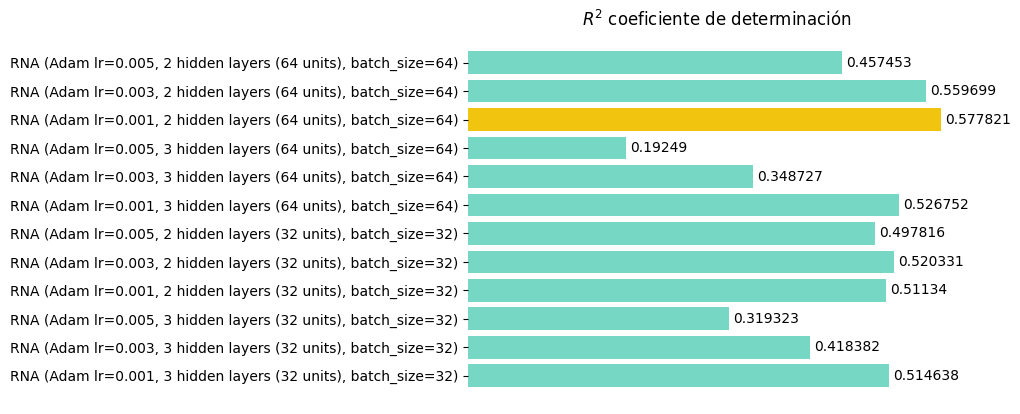

In [ ]:
#Gráfica para los valores de r2
fig, ax = plt.subplots()
B=plt.barh(y=Rna.index,width=Rna.r2_score,color=colores_r2)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title(r'$R^2$ coeficiente de determinación')
ax.tick_params(bottom=False, labelbottom=False);

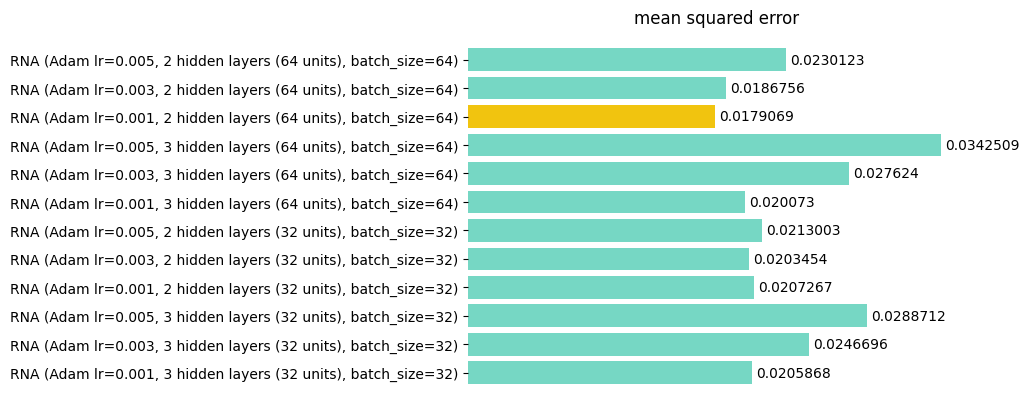

In [ ]:
#Gráfica para los valores de mase
fig, ax = plt.subplots()
B=plt.barh(y=Rna.index,width=Rna.mse,color=colores_mse)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean squared error')
ax.tick_params(bottom=False, labelbottom=False);

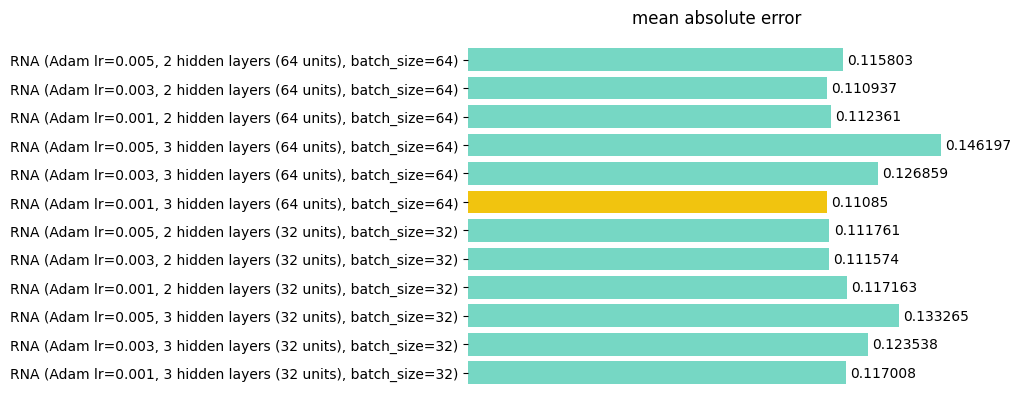

In [ ]:
#Gráfica para los valores de mae
fig, ax = plt.subplots()
B=plt.barh(y=Rna.index,width=Rna.mae, color=colores_mae)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean absolute error')
ax.tick_params(bottom=False, labelbottom=False);

# RNN

### RNN Adam(learning_rate=0.001, units=64, batch_size=32)

In [ ]:
Y_rnn1=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn1=Sequential()
    rnn1.add(SimpleRNN(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn1.add(Dropout(0.1))
    rnn1.add(Dense(1))
    rnn1.compile(optimizer=Adam(learning_rate=0.001),loss='mse')
    rnn1.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn1=rnn1.predict(xtestN)
    Y_rnn1['ypred_'+str(i)]=pd.DataFrame(ypred_rnn1,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.1087 - val_loss: 0.0413
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0535 - val_loss: 0.0211
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0349 - val_loss: 0.0247
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0372 - val_loss: 0.0324
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0465 - val_loss: 0.0281
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0438 - val_loss: 0.0202
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0370 - val_loss: 0.0149
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0320 - val_loss: 0.0122
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0285 - val_loss: 0.0108
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0279 - val_loss: 0.0106
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0301 - val_loss: 0.0107
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0266 - val_lo

In [ ]:
w1=[]
l1=[]
b1=[]
for i in range(4):
    w1.append(r2_score(Y_rnn1.iloc[:,0], Y_rnn1.iloc[:,i+1]))
    b1.append(mean_squared_error(Y_rnn1.iloc[:,0], Y_rnn1.iloc[:,i+1]))
    l1.append(mean_absolute_error(Y_rnn1.iloc[:,0], Y_rnn1.iloc[:,i+1]))

print(w1)
print(l1)
print(b1)

[-0.5755979953935311, -0.005612637323658243, -0.18058677639710008, -0.07158049679388423]
[0.200339036778142, 0.16029186503828732, 0.17252084604251613, 0.15285924944030183]
[0.06682967519963345, 0.04265349798963244, 0.05007510230545475, 0.04545155348024579]


### RNN Adam(learning_rate=0.003, units=64, batch_size=32)

In [ ]:
Y_rnn2=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn2=Sequential()
    rnn2.add(SimpleRNN(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn2.add(Dropout(0.1))
    rnn2.add(Dense(1))
    rnn2.compile(optimizer=Adam(learning_rate=0.003),loss='mse')
    rnn2.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn2=rnn2.predict(xtestN)
    Y_rnn2['ypred_'+str(i)]=pd.DataFrame(ypred_rnn2,index=ytestN.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 0.0936 - val_loss: 0.0223
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0412 - val_loss: 0.0271
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0504 - val_loss: 0.0137
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0346 - val_loss: 0.0094
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0296 - val_loss: 0.0084
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0275 - val_loss: 0.0087
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0266 - val_loss: 0.0095
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0289 - val_loss: 0.0098
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0293 - val_loss: 0.0101
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0313 - val_loss: 0.0099
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0292 - val_loss: 0.0097
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0264 - val_l

In [ ]:
w2=[]
l2=[]
b2=[]
for i in range(4):
    w2.append(r2_score(Y_rnn2.iloc[:,0], Y_rnn2.iloc[:,i+1]))
    b2.append(mean_squared_error(Y_rnn2.iloc[:,0], Y_rnn2.iloc[:,i+1]))
    l2.append(mean_absolute_error(Y_rnn2.iloc[:,0], Y_rnn2.iloc[:,i+1]))

print(w2)
print(l2)
print(b2)

[0.029486528657261202, -0.14773363996231859, -0.13361606647966173, 0.051636796959852016]
[0.14571218967179903, 0.16679710663301792, 0.16296923866397456, 0.1516498417285336]
[0.041164751577704564, 0.04868162221494644, 0.04808281918700956, 0.04022523830047603]


### RNN Adam(learning_rate=0.005, units=64, batch_size=32)

In [ ]:
Y_rnn3=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn3=Sequential()
    rnn3.add(SimpleRNN(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn3.add(Dropout(0.1))
    rnn3.add(Dense(1))
    rnn3.compile(optimizer=Adam(learning_rate=0.005),loss='mse')
    rnn3.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn3=rnn3.predict(xtestN)
    Y_rnn3['ypred_'+str(i)]=pd.DataFrame(ypred_rnn3,index=ytestN.index)

In [ ]:
w3=[]
l3=[]
b3=[]
for i in range(4):
    w3.append(r2_score(Y_rnn3.iloc[:,0], Y_rnn3.iloc[:,i+1]))
    b3.append(mean_squared_error(Y_rnn3.iloc[:,0], Y_rnn3.iloc[:,i+1]))
    l3.append(mean_absolute_error(Y_rnn3.iloc[:,0], Y_rnn3.iloc[:,i+1]))

print(w3)
print(l3)
print(b3)

### RNN Adam(learning_rate=0.001, units=64, batch_size=64)

In [ ]:
Y_rnn4=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn4=Sequential()
    rnn4.add(SimpleRNN(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn4.add(Dropout(0.1))
    rnn4.add(Dense(1))
    rnn4.compile(optimizer=Adam(learning_rate=0.001),loss='mse')
    rnn4.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn4=rnn4.predict(xtestN)
    Y_rnn4['ypred_'+str(i)]=pd.DataFrame(ypred_rnn4,index=ytestN.index)

In [ ]:
w4=[]
l4=[]
b4=[]
for i in range(4):
    w4.append(r2_score(Y_rnn4.iloc[:,0], Y_rnn4.iloc[:,i+1]))
    b4.append(mean_squared_error(Y_rnn4.iloc[:,0], Y_rnn4.iloc[:,i+1]))
    l4.append(mean_absolute_error(Y_rnn4.iloc[:,0], Y_rnn4.iloc[:,i+1]))

print(w4)
print(l4)
print(b4)

### RNN Adam(learning_rate=0.003, units=64, batch_size=64)

In [ ]:
Y_rnn5=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn5=Sequential()
    rnn5.add(SimpleRNN(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn5.add(Dropout(0.1))
    rnn5.add(Dense(1))
    rnn5.compile(optimizer=Adam(learning_rate=0.003),loss='mse')
    rnn5.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn5=rnn5.predict(xtestN)
    Y_rnn5['ypred_'+str(i)]=pd.DataFrame(ypred_rnn5,index=ytestN.index)

In [ ]:
w5=[]
l5=[]
b5=[]
for i in range(4):
    w5.append(r2_score(Y_rnn5.iloc[:,0], Y_rnn5.iloc[:,i+1]))
    b5.append(mean_squared_error(Y_rnn5.iloc[:,0], Y_rnn5.iloc[:,i+1]))
    l5.append(mean_absolute_error(Y_rnn5.iloc[:,0], Y_rnn5.iloc[:,i+1]))

print(w5)
print(l5)
print(b5)

### RNN Adam(learning_rate=0.005, units=64, batch_size=64)

In [ ]:
Y_rnn6=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn6=Sequential()
    rnn6.add(SimpleRNN(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn6.add(Dropout(0.1))
    rnn6.add(Dense(1))
    rnn6.compile(optimizer=Adam(learning_rate=0.005),loss='mse')
    rnn6.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn6=rnn6.predict(xtestN)
    Y_rnn6['ypred_'+str(i)]=pd.DataFrame(ypred_rnn6,index=ytestN.index)

In [ ]:
w6=[]
l6=[]
b6=[]
for i in range(4):
    w6.append(r2_score(Y_rnn6.iloc[:,0], Y_rnn6.iloc[:,i+1]))
    b6.append(mean_squared_error(Y_rnn6.iloc[:,0], Y_rnn6.iloc[:,i+1]))
    l6.append(mean_absolute_error(Y_rnn6.iloc[:,0], Y_rnn6.iloc[:,i+1]))

print(w6)
print(l6)
print(b6)

### RNN Adam(learning_rate=0.003, units=32, batch_size=32)

In [ ]:
Y_rnn8=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn8=Sequential()
    rnn8.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn8.add(Dropout(0.1))
    rnn8.add(Dense(1))
    rnn8.compile(optimizer=Adam(learning_rate=0.003),loss='mse')
    rnn8.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn8=rnn8.predict(xtestN)
    Y_rnn8['ypred_'+str(i)]=pd.DataFrame(ypred_rnn8,index=ytestN.index)

In [ ]:
w8=[]
l8=[]
b8=[]
for i in range(4):
    w8.append(r2_score(Y_rnn8.iloc[:,0], Y_rnn8.iloc[:,i+1]))
    b8.append(mean_squared_error(Y_rnn8.iloc[:,0], Y_rnn8.iloc[:,i+1]))
    l8.append(mean_absolute_error(Y_rnn8.iloc[:,0], Y_rnn8.iloc[:,i+1]))

print(w8)
print(l8)
print(b8)

### RNN Adam(learning_rate=0.005, units=32, batch_size=32)

In [ ]:
Y_rnn9=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn9=Sequential()
    rnn9.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn9.add(Dropout(0.1))
    rnn9.add(Dense(1))
    rnn9.compile(optimizer=Adam(learning_rate=0.005),loss='mse')
    rnn9.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn9=rnn9.predict(xtestN)
    Y_rnn9['ypred_'+str(i)]=pd.DataFrame(ypred_rnn9,index=ytestN.index)

In [ ]:
w9=[]
l9=[]
b9=[]
for i in range(4):
    w9.append(r2_score(Y_rnn9.iloc[:,0], Y_rnn9.iloc[:,i+1]))
    l9.append(mean_absolute_error(Y_rnn9.iloc[:,0], Y_rnn9.iloc[:,i+1]))
    b9.append(mean_squared_error(Y_rnn9.iloc[:,0], Y_rnn9.iloc[:,i+1]))

print(b9)
print(l9)
print(w9)

### RNN Adam(learning_rate=0.001, units=32, batch_size=32)

In [ ]:
Y_rnn7=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn7=Sequential()
    rnn7.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn7.add(Dropout(0.1))
    rnn7.add(Dense(1))
    rnn7.compile(optimizer='Adam',loss='mse')
    rnn7.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn7=rnn7.predict(xtestN)
    Y_rnn7['ypred_'+str(i)]=pd.DataFrame(ypred_rnn7,index=ytestN.index)

In [ ]:
w7=[]
l7=[]
b7=[]
for i in range(4):
    w7.append(r2_score(Y_rnn7.iloc[:,0], Y_rnn7.iloc[:,i+1]))
    b7.append(mean_squared_error(Y_rnn7.iloc[:,0], Y_rnn7.iloc[:,i+1]))
    l7.append(mean_absolute_error(Y_rnn7.iloc[:,0], Y_rnn7.iloc[:,i+1]))

print(w7)
print(l7)
print(b7)

### RNN Adam(learning_rate=0.001, units=32, batch_size=64)

In [ ]:
Y_rnn10=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn10=Sequential()
    rnn10.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn10.add(Dropout(0.1))
    rnn10.add(Dense(1))
    rnn10.compile(optimizer='Adam',loss='mse')
    rnn10.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn10=rnn10.predict(xtestN)
    Y_rnn10['ypred_'+str(i)]=pd.DataFrame(ypred_rnn10,index=ytestN.index)

In [ ]:
w10=[]
l10=[]
b10=[]
for i in range(4):
    w10.append(r2_score(Y_rnn10.iloc[:,0], Y_rnn10.iloc[:,i+1]))
    b10.append(mean_squared_error(Y_rnn10.iloc[:,0], Y_rnn10.iloc[:,i+1]))
    l10.append(mean_absolute_error(Y_rnn10.iloc[:,0], Y_rnn10.iloc[:,i+1]))

print(w10)
print(l10)
print(b10)

### RNN Adam(learning_rate=0.003, units=32, batch_size=64)

In [ ]:
Y_rnn11=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn11=Sequential()
    rnn11.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn11.add(Dropout(0.1))
    rnn11.add(Dense(1))
    rnn11.compile(optimizer=Adam(learning_rate=0.003),loss='mse')
    rnn11.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn11=rnn11.predict(xtestN)
    Y_rnn11['ypred_'+str(i)]=pd.DataFrame(ypred_rnn11,index=ytestN.index)

In [ ]:
w11=[]
l11=[]
b11=[]
for i in range(4):
    w11.append(r2_score(Y_rnn11.iloc[:,0], Y_rnn11.iloc[:,i+1]))
    l11.append(mean_absolute_error(Y_rnn11.iloc[:,0], Y_rnn11.iloc[:,i+1]))
    b11.append(mean_squared_error(Y_rnn11.iloc[:,0], Y_rnn11.iloc[:,i+1]))

print(b11)
print(l11)
print(w11)

### RNN Adam(learning_rate=0.005, units=32, batch_size=64)

In [ ]:
Y_rnn12=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    rnn12=Sequential()
    rnn12.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn12.add(Dropout(0.1))
    rnn12.add(Dense(1))
    rnn12.compile(optimizer=Adam(learning_rate=0.005),loss='mse')
    rnn12.fit(xtrainN,ytrainN,batch_size=64,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn12=rnn12.predict(xtestN)
    Y_rnn12['ypred_'+str(i)]=pd.DataFrame(ypred_rnn12,index=ytestN.index)

In [ ]:
w12=[]
l12=[]
b12=[]
for i in range(4):
    w12.append(r2_score(Y_rnn12.iloc[:,0], Y_rnn12.iloc[:,i+1]))
    l12.append(mean_absolute_error(Y_rnn12.iloc[:,0], Y_rnn12.iloc[:,i+1]))
    b12.append(mean_squared_error(Y_rnn12.iloc[:,0], Y_rnn12.iloc[:,i+1]))

print(b12)
print(l12)
print(w12)

In [ ]:
rnn1={'RNN (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(w1),
    'RNN (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(w2),
    'RNN (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(w3),
    'RNN (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(w4),
    'RNN (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(w5),
    'RNN (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(w6),
    'RNN (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(w7),
    'RNN (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(w8),
    'RNN (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(w9),
    'RNN (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(w10),
    'RNN (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(w11),
    'RNN (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(w12)}

rnn2={'RNN (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(b1),
    'RNN (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(b2),
    'RNN (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(b3),
    'RNN (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(b4),
    'RNN (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(b5),
    'RNN (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(b6),
    'RNN (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(b7),
    'RNN (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(b8),
    'RNN (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(b9),
    'RNN (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(b10),
    'RNN (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(b11),
    'RNN (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(b12)}

rnn3={'RNN (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(l1),
    'RNN (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(l2),
    'RNN (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(l3),
    'RNN (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(l4),
    'RNN (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(l5),
    'RNN (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(l6),
    'RNN (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(l7),
    'RNN (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(l8),
    'RNN (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(l9),
    'RNN (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(l10),
    'RNN (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(l11),
    'RNN (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(l12)}

In [ ]:
Rnn1=pd.DataFrame(rnn1.values(),index=rnn1.keys(),columns=['r2_score'])
Rnn2=pd.DataFrame(rnn2.values(),index=rnn2.keys(),columns=['mse'])
Rnn3=pd.DataFrame(rnn3.values(),index=rnn3.keys(),columns=['mae'])
Rnn=pd.concat([Rnn1,Rnn2,Rnn3],axis=1)
rnn_max=Rnn[Rnn.r2_score==max(Rnn.r2_score)]

In [ ]:
colores_r2=['#f1c40f' if i==max(Rnn.r2_score) else '#76d7c4' for i in Rnn.r2_score]
colores_mse=['#f1c40f' if i==min(Rnn.mse) else '#76d7c4' for i in Rnn.mse]
colores_mae=['#f1c40f' if i==min(Rnn.mae) else '#76d7c4' for i in Rnn.mae]

In [ ]:
#Gráfica para los valores de r2
fig, ax = plt.subplots()
B=plt.barh(y=Rnn.index,width=Rnn.r2_score,color=colores_r2)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title(r'$R^2$ coeficiente de determinación')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mase
fig, ax = plt.subplots()
B=plt.barh(y=Rnn.index,width=Rnn.mse,color=colores_mse)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean squared error')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mae
fig, ax = plt.subplots()
B=plt.barh(y=Rnn.index,width=Rnn.mae, color=colores_mae)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean absolute error')
ax.tick_params(bottom=False, labelbottom=False);

# LSTM

### LSTM Adam(learning_rate=0.001, units=64, batch_size=32)

In [ ]:
Y_lstm1=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm1 = Sequential()
    lstm1.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm1.add(Dropout(0.1))
    lstm1.add(Dense(1))
    lstm1.compile(optimizer='adam', loss='mse')
    lstm1.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm1=lstm1.predict(xtestN)
    Y_lstm1['ypred_'+str(i)]=pd.DataFrame(ypred_lstm1,index=ytestN.index)

In [ ]:
u1=[]
m1=[]
c1=[]
for i in range(4):
    u1.append(r2_score(Y_lstm1.iloc[:,0], Y_lstm1.iloc[:,i+1]))
    c1.append(mean_squared_error(Y_lstm1.iloc[:,0], Y_lstm1.iloc[:,i+1]))
    m1.append(mean_absolute_error(Y_lstm1.iloc[:,0], Y_lstm1.iloc[:,i+1]))

print(u1)
print(m1)
print(c1)

### LSTM Adam(learning_rate=0.003, units=64, batch_size=32)

In [ ]:
Y_lstm2=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm2 = Sequential()
    lstm2.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm2.add(Dropout(0.1))
    lstm2.add(Dense(1))
    lstm2.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    lstm2.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm2=lstm2.predict(xtestN)
    Y_lstm2['ypred_'+str(i)]=pd.DataFrame(ypred_lstm2,index=ytestN.index)

In [ ]:
u2=[]
m2=[]
c2=[]
for i in range(4):
    u2.append(r2_score(Y_lstm2.iloc[:,0], Y_lstm2.iloc[:,i+1]))
    c2.append(mean_squared_error(Y_lstm2.iloc[:,0], Y_lstm2.iloc[:,i+1]))
    m2.append(mean_absolute_error(Y_lstm2.iloc[:,0], Y_lstm2.iloc[:,i+1]))

print(u2)
print(m2)
print(c2)

### LSTM Adam(learning_rate=0.005, units=64, batch_size=32)

In [ ]:
Y_lstm3=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm3 = Sequential()
    lstm3.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm3.add(Dropout(0.1))
    lstm3.add(Dense(1))
    lstm3.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    lstm3.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm3=lstm3.predict(xtestN)
    Y_lstm3['ypred_'+str(i)]=pd.DataFrame(ypred_lstm3,index=ytestN.index)

In [ ]:
u3=[]
m3=[]
c3=[]
for i in range(4):
    u3.append(r2_score(Y_lstm3.iloc[:,0], Y_lstm3.iloc[:,i+1]))
    c3.append(mean_squared_error(Y_lstm3.iloc[:,0], Y_lstm3.iloc[:,i+1]))
    m3.append(mean_absolute_error(Y_lstm3.iloc[:,0], Y_lstm3.iloc[:,i+1]))

print(u3)
print(m3)
print(c3)

### LSTM Adam(learning_rate=0.001, units=64, batch_size=64)

In [ ]:
Y_lstm4=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm4 = Sequential()
    lstm4.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm4.add(Dropout(0.1))
    lstm4.add(Dense(1))
    lstm4.compile(optimizer='adam', loss='mse')
    lstm4.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm4=lstm4.predict(xtestN)
    Y_lstm4['ypred_'+str(i)]=pd.DataFrame(ypred_lstm4,index=ytestN.index)

In [ ]:
u4=[]
m4=[]
c4=[]
for i in range(4):
    u4.append(r2_score(Y_lstm4.iloc[:,0], Y_lstm4.iloc[:,i+1]))
    c4.append(mean_squared_error(Y_lstm4.iloc[:,0], Y_lstm4.iloc[:,i+1]))
    m4.append(mean_absolute_error(Y_lstm4.iloc[:,0], Y_lstm4.iloc[:,i+1]))

print(u4)
print(m4)
print(c4)

### LSTM Adam(learning_rate=0.003, units=64, batch_size=64)

In [ ]:
Y_lstm5=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm5 = Sequential()
    lstm5.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm5.add(Dropout(0.1))
    lstm5.add(Dense(1))
    lstm5.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    lstm5.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm5=lstm5.predict(xtestN)
    Y_lstm5['ypred_'+str(i)]=pd.DataFrame(ypred_lstm5,index=ytestN.index)

In [ ]:
u5=[]
m5=[]
c5=[]
for i in range(4):
    u5.append(r2_score(Y_lstm5.iloc[:,0], Y_lstm5.iloc[:,i+1]))
    c5.append(mean_squared_error(Y_lstm5.iloc[:,0], Y_lstm5.iloc[:,i+1]))
    m5.append(mean_absolute_error(Y_lstm5.iloc[:,0], Y_lstm5.iloc[:,i+1]))

print(u5)
print(m5)
print(c5)

### LSTM Adam(learning_rate=0.005, units=64, batch_size=64)

In [ ]:
Y_lstm6=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm6 = Sequential()
    lstm6.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm6.add(Dropout(0.1))
    lstm6.add(Dense(1))
    lstm6.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    lstm6.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm6=lstm6.predict(xtestN)
    Y_lstm6['ypred_'+str(i)]=pd.DataFrame(ypred_lstm6,index=ytestN.index)

In [ ]:
u6=[]
m6=[]
c6=[]
for i in range(4):
    u6.append(r2_score(Y_lstm6.iloc[:,0], Y_lstm6.iloc[:,i+1]))
    c6.append(mean_squared_error(Y_lstm6.iloc[:,0], Y_lstm6.iloc[:,i+1]))
    m6.append(mean_absolute_error(Y_lstm6.iloc[:,0], Y_lstm6.iloc[:,i+1]))

print(u6)
print(m6)
print(c6)

### LSTM Adam(learning_rate=0.001, units=32, batch_size=32)

In [ ]:
Y_lstm7=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm7 = Sequential()
    lstm7.add(LSTM(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm7.add(Dropout(0.1))
    lstm7.add(Dense(1))
    lstm7.compile(optimizer='adam', loss='mse')
    lstm7.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm7=lstm7.predict(xtestN)
    Y_lstm7['ypred_'+str(i)]=pd.DataFrame(ypred_lstm7,index=ytestN.index)

In [ ]:
u7=[]
m7=[]
c7=[]
for i in range(4):
    u7.append(r2_score(Y_lstm7.iloc[:,0], Y_lstm7.iloc[:,i+1]))
    c7.append(mean_squared_error(Y_lstm7.iloc[:,0], Y_lstm7.iloc[:,i+1]))
    m7.append(mean_absolute_error(Y_lstm7.iloc[:,0], Y_lstm7.iloc[:,i+1]))

print(u7)
print(m7)
print(c7)

### LSTM Adam(learning_rate=0.003, units=32, batch_size=32)

In [ ]:
Y_lstm8=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm8 = Sequential()
    lstm8.add(LSTM(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm8.add(Dropout(0.1))
    lstm8.add(Dense(1))
    lstm8.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    lstm8.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm8=lstm8.predict(xtestN)
    Y_lstm8['ypred_'+str(i)]=pd.DataFrame(ypred_lstm8,index=ytestN.index)

In [ ]:
u8=[]
m8=[]
c8=[]
for i in range(4):
    u8.append(r2_score(Y_lstm8.iloc[:,0], Y_lstm8.iloc[:,i+1]))
    c8.append(mean_squared_error(Y_lstm8.iloc[:,0], Y_lstm8.iloc[:,i+1]))
    m8.append(mean_absolute_error(Y_lstm8.iloc[:,0], Y_lstm8.iloc[:,i+1]))

print(u8)
print(m8)
print(c8)

### LSTM Adam(learning_rate=0.005, units=32, batch_size=32)

In [ ]:
Y_lstm9=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm9 = Sequential()
    lstm9.add(LSTM(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm9.add(Dropout(0.1))
    lstm9.add(Dense(1))
    lstm9.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    lstm9.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm9=lstm9.predict(xtestN)
    Y_lstm9['ypred_'+str(i)]=pd.DataFrame(ypred_lstm9,index=ytestN.index)

In [ ]:
u9=[]
m9=[]
c9=[]
for i in range(4):
    u9.append(r2_score(Y_lstm9.iloc[:,0], Y_lstm9.iloc[:,i+1]))
    c9.append(mean_squared_error(Y_lstm9.iloc[:,0], Y_lstm9.iloc[:,i+1]))
    m9.append(mean_absolute_error(Y_lstm9.iloc[:,0], Y_lstm9.iloc[:,i+1]))

print(u9)
print(m9)
print(c9)

### LSTM Adam(learning_rate=0.001, units=32, batch_size=64)

In [ ]:
Y_lstm10=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm10 = Sequential()
    lstm10.add(LSTM(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm10.add(Dropout(0.1))
    lstm10.add(Dense(1))
    lstm10.compile(optimizer='adam', loss='mse')
    lstm10.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm10=lstm10.predict(xtestN)
    Y_lstm10['ypred_'+str(i)]=pd.DataFrame(ypred_lstm10,index=ytestN.index)

In [ ]:
u10=[]
m10=[]
c10=[]
for i in range(4):
    u10.append(r2_score(Y_lstm10.iloc[:,0], Y_lstm10.iloc[:,i+1]))
    c10.append(mean_squared_error(Y_lstm10.iloc[:,0], Y_lstm10.iloc[:,i+1]))
    m10.append(mean_absolute_error(Y_lstm10.iloc[:,0], Y_lstm10.iloc[:,i+1]))

print(u10)
print(m10)
print(c10)

### LSTM Adam(learning_rate=0.003, units=32, batch_size=64)

In [ ]:
Y_lstm11=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm11 = Sequential()
    lstm11.add(LSTM(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm11.add(Dropout(0.1))
    lstm11.add(Dense(1))
    lstm11.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    lstm11.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm11=lstm11.predict(xtestN)
    Y_lstm11['ypred_'+str(i)]=pd.DataFrame(ypred_lstm11,index=ytestN.index)

In [ ]:
u11=[]
m11=[]
c11=[]
for i in range(4):
    u11.append(r2_score(Y_lstm11.iloc[:,0], Y_lstm11.iloc[:,i+1]))
    c11.append(mean_squared_error(Y_lstm11.iloc[:,0], Y_lstm11.iloc[:,i+1]))
    m11.append(mean_absolute_error(Y_lstm11.iloc[:,0], Y_lstm11.iloc[:,i+1]))

print(u11)
print(m11)
print(c11)

### LSTM Adam(learning_rate=0.005, units=32, batch_size=64)

In [ ]:
Y_lstm12=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    lstm12 = Sequential()
    lstm12.add(LSTM(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm12.add(Dropout(0.1))
    lstm12.add(Dense(1))
    lstm12.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    lstm12.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm12=lstm12.predict(xtestN)
    Y_lstm12['ypred_'+str(i)]=pd.DataFrame(ypred_lstm12,index=ytestN.index)

In [ ]:
u12=[]
m12=[]
c12=[]
for i in range(4):
    u12.append(r2_score(Y_lstm12.iloc[:,0], Y_lstm12.iloc[:,i+1]))
    c12.append(mean_squared_error(Y_lstm12.iloc[:,0], Y_lstm12.iloc[:,i+1]))
    m12.append(mean_absolute_error(Y_lstm12.iloc[:,0], Y_lstm12.iloc[:,i+1]))

print(u12)
print(m12)
print(c12)

In [ ]:
lstm1={'LSTM (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(u1),
    'LSTM (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(u2),
    'LSTM (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(u3),
    'LSTM (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(u4),
    'LSTM (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(u5),
    'LSTM (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(u6),
    'LSTM (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(u7),
    'LSTM (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(u8),
    'LSTM (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(u9),
    'LSTM (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(u10),
    'LSTM (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(u11),
    'LSTM (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(u12)}

lstm2={'LSTM (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(c1),
    'LSTM (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(c2),
    'LSTM (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(c3),
    'LSTM (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(c4),
    'LSTM (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(c5),
    'LSTM (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(c6),
    'LSTM (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(c7),
    'LSTM (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(c8),
    'LSTM (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(c9),
    'LSTM (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(c10),
    'LSTM (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(c11),
    'LSTM (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(c12)}

lstm3={'LSTM (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(m1),
    'LSTM (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(m2),
    'LSTM (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(m3),
    'LSTM (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(m4),
    'LSTM (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(m5),
    'LSTM (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(m6),
    'LSTM (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(m7),
    'LSTM (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(m8),
    'LSTM (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(m9),
    'LSTM (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(m10),
    'LSTM (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(m11),
    'LSTM (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(m12)}

In [ ]:
Lstm1=pd.DataFrame(lstm1.values(),index=lstm1.keys(),columns=['r2_score'])
Lstm2=pd.DataFrame(lstm2.values(),index=lstm2.keys(),columns=['mse'])
Lstm3=pd.DataFrame(lstm3.values(),index=lstm3.keys(),columns=['mae'])
Lstm=pd.concat([Lstm1,Lstm2,Lstm3],axis=1)
lstm_max=Lstm[Lstm.r2_score==max(Lstm.r2_score)]

In [ ]:
colores_r2=['#f1c40f' if i==max(Lstm.r2_score) else '#76d7c4' for i in Lstm.r2_score]
colores_mse=['#f1c40f' if i==min(Lstm.mse) else '#76d7c4' for i in Lstm.mse]
colores_mae=['#f1c40f' if i==min(Lstm.mae) else '#76d7c4' for i in Lstm.mae]

In [ ]:
#Gráfica para los valores de r2
fig, ax = plt.subplots()
B=plt.barh(y=Lstm.index,width=Lstm.r2_score,color=colores_r2)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title(r'$R^2$ coeficiente de determinación')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mase
fig, ax = plt.subplots()
B=plt.barh(y=Lstm.index,width=Lstm.mse,color=colores_mse)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean squared error')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mae
fig, ax = plt.subplots()
B=plt.barh(y=Lstm.index,width=Lstm.mae, color=colores_mae)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean absolute error')
ax.tick_params(bottom=False, labelbottom=False);

# GRU

### GRU (Adam learning_rate=0.005, units=64, batch_size=32)

In [ ]:
Y_gru3=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru3 = Sequential()
    gru3.add(GRU(64 , activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru3.add(Dropout(0.1))
    gru3.add(Dense(1))
    gru3.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    gru3.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru3=gru3.predict(xtestN)
    Y_gru3['ypred_'+str(i)]=pd.DataFrame(ypred_gru3,index=ytestN.index)

In [ ]:
y3=[]
n3=[]
d3=[]
for i in range(4):
    y3.append(r2_score(Y_gru3.iloc[:,0], Y_gru3.iloc[:,i+1]))
    n3.append(mean_absolute_error(Y_gru3.iloc[:,0], Y_gru3.iloc[:,i+1]))
    d3.append(mean_squared_error(Y_gru3.iloc[:,0], Y_gru3.iloc[:,i+1]))

print(y3)
print(n3)
print(d3)

### GRU (Adam learning_rate=0.003, units=64, batch_size=32)

In [ ]:
Y_gru2=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru2 = Sequential()
    gru2.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru2.add(Dropout(0.1))
    gru2.add(Dense(1))
    gru2.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    gru2.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru2=gru2.predict(xtestN)
    Y_gru2['ypred_'+str(i)]=pd.DataFrame(ypred_gru2,index=ytestN.index)

In [ ]:
y2=[]
n2=[]
d2=[]
for i in range(4):
    y2.append(r2_score(Y_gru2.iloc[:,0], Y_gru2.iloc[:,i+1]))
    d2.append(mean_squared_error(Y_gru2.iloc[:,0], Y_gru2.iloc[:,i+1]))
    n2.append(mean_absolute_error(Y_gru2.iloc[:,0], Y_gru2.iloc[:,i+1]))

print(y2)
print(n2)
print(d2)

### GRU (Adam learning_rate=0.001, units=64, batch_size=32)

In [ ]:
Y_gru1=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru1 = Sequential()
    gru1.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru1.add(Dropout(0.1))
    gru1.add(Dense(1))
    gru1.compile(optimizer='adam', loss='mse')
    gru1.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru1=gru1.predict(xtestN)
    Y_gru1['ypred_'+str(i)]=pd.DataFrame(ypred_gru1,index=ytestN.index)

In [ ]:
y1=[]
n1=[]
d1=[]
for i in range(4):
    y1.append(r2_score(Y_gru1.iloc[:,0], Y_gru1.iloc[:,i+1]))
    d1.append(mean_squared_error(Y_gru1.iloc[:,0], Y_gru1.iloc[:,i+1]))
    n1.append(mean_absolute_error(Y_gru1.iloc[:,0], Y_gru1.iloc[:,i+1]))

print(y1)
print(n1)
print(d1)

### GRU (Adam learning_rate=0.001, units=64, batch_size=64)

In [ ]:
Y_gru4=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru4 = Sequential()
    gru4.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru4.add(Dropout(0.1))
    gru4.add(Dense(1))
    gru4.compile(optimizer='adam', loss='mse')
    gru4.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru4=gru4.predict(xtestN)
    Y_gru4['ypred_'+str(i)]=pd.DataFrame(ypred_gru4,index=ytestN.index)

In [ ]:
y4=[]
n4=[]
d4=[]
for i in range(4):
    y4.append(r2_score(Y_gru4.iloc[:,0], Y_gru4.iloc[:,i+1]))
    d4.append(mean_squared_error(Y_gru4.iloc[:,0], Y_gru4.iloc[:,i+1]))
    n4.append(mean_absolute_error(Y_gru4.iloc[:,0], Y_gru4.iloc[:,i+1]))

print(y4)
print(n4)
print(d4)

### GRU (Adam learning_rate=0.003, units=64, batch_size=64)

In [ ]:
Y_gru5=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru5 = Sequential()
    gru5.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru5.add(Dropout(0.1))
    gru5.add(Dense(1))
    gru5.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    gru5.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru5=gru5.predict(xtestN)
    Y_gru5['ypred_'+str(i)]=pd.DataFrame(ypred_gru5,index=ytestN.index)

In [ ]:
y5=[]
n5=[]
d5=[]
for i in range(4):
    y5.append(r2_score(Y_gru5.iloc[:,0], Y_gru5.iloc[:,i+1]))
    d5.append(mean_squared_error(Y_gru5.iloc[:,0], Y_gru5.iloc[:,i+1]))
    n5.append(mean_absolute_error(Y_gru5.iloc[:,0], Y_gru5.iloc[:,i+1]))

print(y5)
print(n5)
print(d5)

### GRU (Adam learning_rate=0.005, units=64, batch_size=64)

In [ ]:
Y_gru6=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru6 = Sequential()
    gru6.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru6.add(Dropout(0.1))
    gru6.add(Dense(1))
    gru6.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    gru6.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru6=gru6.predict(xtestN)
    Y_gru6['ypred_'+str(i)]=pd.DataFrame(ypred_gru6,index=ytestN.index)

In [ ]:
y6=[]
n6=[]
d6=[]
for i in range(4):
    y6.append(r2_score(Y_gru6.iloc[:,0], Y_gru6.iloc[:,i+1]))
    d6.append(mean_squared_error(Y_gru6.iloc[:,0], Y_gru6.iloc[:,i+1]))
    n6.append(mean_absolute_error(Y_gru6.iloc[:,0], Y_gru6.iloc[:,i+1]))

print(y6)
print(n6)
print(d6)

### GRU (Adam learning_rate=0.001, units=32, batch_size=32)

In [ ]:
Y_gru7=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru7= Sequential()
    gru7.add(GRU(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru7.add(Dropout(0.1))
    gru7.add(Dense(1))
    gru7.compile(optimizer='adam', loss='mse')
    gru7.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru7=gru7.predict(xtestN)
    Y_gru7['ypred_'+str(i)]=pd.DataFrame(ypred_gru7,index=ytestN.index)

In [ ]:
y7=[]
n7=[]
d7=[]
for i in range(4):
    y7.append(r2_score(Y_gru7.iloc[:,0], Y_gru7.iloc[:,i+1]))
    d7.append(mean_squared_error(Y_gru7.iloc[:,0], Y_gru7.iloc[:,i+1]))
    n7.append(mean_absolute_error(Y_gru7.iloc[:,0], Y_gru7.iloc[:,i+1]))

print(y7)
print(n7)
print(d7)

### GRU (Adam learning_rate=0.003, units=32, batch_size=32)

In [ ]:
Y_gru8=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru8 = Sequential()
    gru8.add(GRU(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru8.add(Dropout(0.1))
    gru8.add(Dense(1))
    gru8.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    gru8.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru8=gru8.predict(xtestN)
    Y_gru8['ypred_'+str(i)]=pd.DataFrame(ypred_gru8,index=ytestN.index)

In [ ]:
y8=[]
n8=[]
d8=[]
for i in range(4):
    y8.append(r2_score(Y_gru8.iloc[:,0], Y_gru8.iloc[:,i+1]))
    d8.append(mean_squared_error(Y_gru8.iloc[:,0], Y_gru8.iloc[:,i+1]))
    n8.append(mean_absolute_error(Y_gru8.iloc[:,0], Y_gru8.iloc[:,i+1]))

print(y8)
print(n8)
print(d8)

### GRU (Adam learning_rate=0.005, units=32, batch_size=32)

In [ ]:
Y_gru9=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru9 = Sequential()
    gru9.add(GRU(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru9.add(Dropout(0.1))
    gru9.add(Dense(1))
    gru9.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    gru9.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru9=gru9.predict(xtestN)
    Y_gru9['ypred_'+str(i)]=pd.DataFrame(ypred_gru9,index=ytestN.index)

In [ ]:
y9=[]
n9=[]
d9=[]
for i in range(4):
    y9.append(r2_score(Y_gru9.iloc[:,0], Y_gru9.iloc[:,i+1]))
    d9.append(mean_squared_error(Y_gru9.iloc[:,0], Y_gru9.iloc[:,i+1]))
    n9.append(mean_absolute_error(Y_gru9.iloc[:,0], Y_gru9.iloc[:,i+1]))

print(y9)
print(n9)
print(d9)

### GRU (Adam learning_rate=0.001, units=32, batch_size=64)

In [ ]:
Y_gru10=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru10 = Sequential()
    gru10.add(GRU(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru10.add(Dropout(0.1))
    gru10.add(Dense(1))
    gru10.compile(optimizer='adam', loss='mse')
    gru10.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru10=gru10.predict(xtestN)
    Y_gru10['ypred_'+str(i)]=pd.DataFrame(ypred_gru10,index=ytestN.index)

In [ ]:
y10=[]
n10=[]
d10=[]
for i in range(4):
    y10.append(r2_score(Y_gru10.iloc[:,0], Y_gru10.iloc[:,i+1]))
    d10.append(mean_squared_error(Y_gru10.iloc[:,0], Y_gru10.iloc[:,i+1]))
    n10.append(mean_absolute_error(Y_gru10.iloc[:,0], Y_gru10.iloc[:,i+1]))

print(y10)
print(n10)
print(d10)

### GRU (Adam learning_rate=0.003, units=32, batch_size=64)

In [ ]:
Y_gru11=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru11 = Sequential()
    gru11.add(GRU(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru11.add(Dropout(0.1))
    gru11.add(Dense(1))
    gru11.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    gru11.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru11=gru11.predict(xtestN)
    Y_gru11['ypred_'+str(i)]=pd.DataFrame(ypred_gru11,index=ytestN.index)

In [ ]:
y11=[]
n11=[]
d11=[]
for i in range(4):
    y11.append(r2_score(Y_gru11.iloc[:,0], Y_gru11.iloc[:,i+1]))
    d11.append(mean_squared_error(Y_gru11.iloc[:,0], Y_gru11.iloc[:,i+1]))
    n11.append(mean_absolute_error(Y_gru11.iloc[:,0], Y_gru11.iloc[:,i+1]))

print(y11)
print(n11)
print(d11)

### GRU (Adam learning_rate=0.005, units=32, batch_size=64)

In [ ]:
Y_gru12=pd.DataFrame(ytestN,index=ytestN.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru12 = Sequential()
    gru12.add(GRU(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru12.add(Dropout(0.1))
    gru12.add(Dense(1))
    gru12.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    gru12.fit(xtrainN, ytrainN, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru12=gru12.predict(xtestN)
    Y_gru12['ypred_'+str(i)]=pd.DataFrame(ypred_gru12,index=ytestN.index)

In [ ]:
y12=[]
n12=[]
d12=[]
for i in range(4):
    y12.append(r2_score(Y_gru12.iloc[:,0], Y_gru12.iloc[:,i+1]))
    d12.append(mean_squared_error(Y_gru12.iloc[:,0], Y_gru12.iloc[:,i+1]))
    n12.append(mean_absolute_error(Y_gru12.iloc[:,0], Y_gru12.iloc[:,i+1]))

print(y12)
print(n12)
print(d12)

In [ ]:
gru1={'GRU (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(y1),
    'GRU (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(y2),
    'GRU (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(y3),
    'GRU (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(y4),
    'GRU (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(y5),
    'GRU (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(y6),
    'GRU (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(y7),
    'GRU (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(y8),
    'GRU (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(y9),
    'GRU (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(y10),
    'GRU (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(y11),
    'GRU (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(y12)}

gru2={'GRU (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(d1),
    'GRU (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(d2),
    'GRU (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(d3),
    'GRU (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(d4),
    'GRU (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(d5),
    'GRU (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(d6),
    'GRU (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(d7),
    'GRU (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(d8),
    'GRU (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(d9),
    'GRU (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(d10),
    'GRU (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(d11),
    'GRU (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(d12)}

gru3={'GRU (Adam lr=0.001, units=64, batch_size=32)': statistics.mean(n1),
    'GRU (Adam lr=0.003, units=64, batch_size=32)': statistics.mean(n2),
    'GRU (Adam lr=0.005, units=64, batch_size=32)': statistics.mean(n3),
    'GRU (Adam lr=0.001, units=64, batch_size=64)': statistics.mean(n4),
    'GRU (Adam lr=0.003, units=64, batch_size=64)': statistics.mean(n5),
    'GRU (Adam lr=0.005, units=64, batch_size=64)': statistics.mean(n6),
    'GRU (Adam lr=0.001, units=32, batch_size=32)': statistics.mean(n7),
    'GRU (Adam lr=0.003, units=32, batch_size=32)': statistics.mean(n8),
    'GRU (Adam lr=0.005, units=32, batch_size=32)': statistics.mean(n9),
    'GRU (Adam lr=0.001, units=32, batch_size=64)': statistics.mean(n10),
    'GRU (Adam lr=0.003, units=32, batch_size=64)': statistics.mean(n11),
    'GRU (Adam lr=0.005, units=32, batch_size=64)': statistics.mean(n12)}

In [ ]:
Gru1=pd.DataFrame(gru1.values(),index=gru1.keys(),columns=['r2_score'])
Gru2=pd.DataFrame(gru2.values(),index=gru2.keys(),columns=['mse'])
Gru3=pd.DataFrame(gru3.values(),index=gru3.keys(),columns=['mae'])
Gru=pd.concat([Gru1,Gru2,Gru3],axis=1)
gru_max=Gru[Gru.r2_score==max(Gru.r2_score)]

In [ ]:
colores_r2=['#f1c40f' if i==max(Gru.r2_score) else '#76d7c4' for i in Gru.r2_score]
colores_mse=['#f1c40f' if i==min(Gru.mse) else '#76d7c4' for i in Gru.mse]
colores_mae=['#f1c40f' if i==min(Gru.mae) else '#76d7c4' for i in Gru.mae]

In [ ]:
#Gráfica para los valores de r2
fig, ax = plt.subplots()
B=plt.barh(y=Gru.index,width=Gru.r2_score,color=colores_r2)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title(r'$R^2$ coeficiente de determinación')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mase
fig, ax = plt.subplots()
B=plt.barh(y=Gru.index,width=Gru.mse,color=colores_mse)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean squared error')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mae
fig, ax = plt.subplots()
B=plt.barh(y=Gru.index,width=Gru.mae, color=colores_mae)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean absolute error')
ax.tick_params(bottom=False, labelbottom=False);

### Resultados

In [ ]:
df=pd.concat([ml_max,lstm_max,gru_max,rnn_max,rna_max])
df

In [ ]:
colores_r2=['#f1c40f' if i==max(df.r2_score) else '#76d7c4' for i in df.r2_score]
colores_mse=['#f1c40f' if i==min(df.mse) else '#76d7c4' for i in df.mse]
colores_mae=['#f1c40f' if i==min(df.mae) else '#76d7c4' for i in df.mae]

In [ ]:
#Gráfica para los valores de r2
fig, ax = plt.subplots()
B=plt.barh(y=df.index,width=df.r2_score,color=colores_r2)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False);
ax.spines['bottom'].set_visible(False)
plt.title(r'$R^2$ coeficiente de determinación')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mase
fig, ax = plt.subplots()
B=plt.barh(y=df.index,width=df.mse,color=colores_mse)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False);
ax.spines['bottom'].set_visible(False)
plt.title('mean squared error')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
#Gráfica para los valores de mae
fig, ax = plt.subplots()
B=plt.barh(y=df.index,width=df.mae, color=colores_mae)
ax.bar_label(B, padding=3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.title('mean absolute error')
ax.tick_params(bottom=False, labelbottom=False);

In [ ]:
print('Fin:',datetime.now())